In [16]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def load_token_id_map(path: Path, encoding="utf-8"):
    """
    Legge file con due colonne: token <whitespace> id
    Ritorna (token_to_id, id_to_token)
    Parsing robusto: prende l'ultimo campo come id (split da destra).
    """
    token_to_id = {}
    id_to_token = {}

    with path.open("r", encoding=encoding) as f:
        for ln, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            # split da destra: ultimo "campo" deve essere l'id
            try:
                token, id_str = line.rsplit(None, 1)  # separa su whitespace, solo 1 split
            except ValueError:
                raise ValueError(f"Linea {ln} non ha 2 colonne: {line!r}")

            try:
                tid = int(id_str)
            except ValueError:
                raise ValueError(f"Linea {ln} id non intero: {id_str!r}")

            token_to_id[token] = tid
            id_to_token[tid] = token

    return token_to_id, id_to_token


def load_grid_structure(path: Path, token_to_id: dict, encoding="utf-8"):
    """
    Legge griglia 4x4 (whitespace-separated) come nel tuo esempio.
    Ritorna:
      GRID: list[list[str]]
      WORD_TO_POS: dict[token] -> (r,c)
      WORD_TO_TID: dict[token] -> id
      ID_TO_WORD: dict[id] -> token
      ROW_LABELS: list[str]
    """
    rows = []
    with path.open("r", encoding=encoding) as f:
        for ln, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            row = line.split()
            rows.append(row)

    if len(rows) != 4 or any(len(r) != 4 for r in rows):
        raise ValueError(f"Griglia attesa 4x4, trovata {len(rows)} righe con lunghezze {[len(r) for r in rows]}")

    GRID = rows

    WORD_TO_POS = {w: (r, c) for r, row in enumerate(GRID) for c, w in enumerate(row)}

    # Map token->id usando il vocabolario caricato
    missing = [w for w in WORD_TO_POS.keys() if w not in token_to_id]
    if missing:
        raise KeyError(
            "Token della griglia mancanti nel file token-id. Esempi: "
            + ", ".join(missing[:8])
            + (" ..." if len(missing) > 8 else "")
        )

    WORD_TO_TID = {w: token_to_id[w] for w in WORD_TO_POS.keys()}
    ID_TO_WORD = {tid: w for w, tid in WORD_TO_TID.items()}

    ROW_LABELS = [f"Row {r}: " + " ".join(GRID[r]) for r in range(4)]

    return GRID, WORD_TO_POS, WORD_TO_TID, ID_TO_WORD, ROW_LABELS


def load_embeddings_pt(pt_path: Path, emb_key="embeddings_last", ids_key="input_ids_last"):
    """
    Carica un .pt nel tuo formato e ritorna:
      ids_np: (L,) int64
      emb_np: (L, D) float32
    Gestisce anche il caso (1, L) e (1, L, D).
    """
    obj = torch.load(pt_path, map_location="cpu", weights_only=False)
    ids = obj[ids_key]
    emb = obj[emb_key]

    # squeeze batch dimension se presente
    if ids.ndim == 2 and ids.shape[0] == 1:
        ids = ids[0]
    if emb.ndim == 3 and emb.shape[0] == 1:
        emb = emb[0]

    ids_np = ids.detach().cpu().numpy()
    emb_np = emb.detach().cpu().float().numpy()

    return ids_np, emb_np

def grid_edges_from_grid(GRID, WORD_TO_TID, available_tids=None):
    """
    Ritorna lista di (tid1, tid2) per celle adiacenti (4-neighbors) in GRID.
    Se available_tids è dato, filtra solo coppie con entrambi in available_tids.
    """
    n_rows = len(GRID)
    n_cols = len(GRID[0]) if n_rows else 0

    edges = []
    for r in range(n_rows):
        for c in range(n_cols):
            w1 = GRID[r][c]
            t1 = WORD_TO_TID[w1]
            for rr, cc in [(r-1,c), (r+1,c), (r,c-1), (r,c+1)]:
                if 0 <= rr < n_rows and 0 <= cc < n_cols:
                    w2 = GRID[rr][cc]
                    t2 = WORD_TO_TID[w2]
                    if t1 < t2:
                        if available_tids is None or (t1 in available_tids and t2 in available_tids):
                            edges.append((t1, t2))
    return edges



def plot_window_pca_grid(
    all_ids_np,
    all_emb_np,
    GRID,
    WORD_TO_POS,
    WORD_TO_TID,
    ID_TO_WORD,
    row_colors,
    row_labels,
    NW=200,
    random_state=0,
    point_size=60,
    alpha=0.75,
    title_prefix="Single random walk",
):
    """
    - Prende ids/embeddings (numpy) di una sequenza
    - Finestra sugli ultimi NW token
    - PCA 2D sugli embeddings finestrati
    - Calcola centroidi per token-id
    - Disegna edges (griglia), scatter e annotazioni
    """
    L_total = len(all_ids_np)
    W = min(NW, L_total)

    win_ids = all_ids_np[-W:]
    win_emb = all_emb_np[-W:]

    print(f"Window: {len(win_ids)} timesteps (file length {L_total})")
    print(f"Unique tokens in window: {len(np.unique(win_ids))}")

    # PCA
    pca_win = PCA(n_components=2, random_state=random_state)
    Z_win = pca_win.fit_transform(win_emb)

    # Centroidi per token-id
    unique_win = np.unique(win_ids)
    centroids = {int(t): Z_win[win_ids == t].mean(axis=0) for t in unique_win}

    fig, ax = plt.subplots(figsize=(9, 7))

    # Edges della griglia (solo se entrambi i token appaiono in finestra)
    edges = grid_edges_from_grid(GRID, WORD_TO_TID, available_tids=set(centroids))
    for t1, t2 in edges:
        c1, c2 = centroids[t1], centroids[t2]
        ax.plot([c1[0], c2[0]], [c1[1], c2[1]], color="#cccccc", lw=1, zorder=1)

    legend_added = set()

    for tid in unique_win:
        tid_int = int(tid)
        mask = (win_ids == tid)

        # Se il token-id è nella griglia, ottengo la parola e la riga
        if tid_int in ID_TO_WORD:
            word = ID_TO_WORD[tid_int]
            row_g, _ = WORD_TO_POS[word]
            color = row_colors[row_g]
            label = row_labels[row_g] if row_g not in legend_added else None
            legend_added.add(row_g)
        else:
            # token non nella griglia
            word = str(tid_int)
            color = "grey"
            label = None

        ax.scatter(
            Z_win[mask, 0], Z_win[mask, 1],
            s=point_size, alpha=alpha, color=color,
            edgecolors="k", linewidths=0.3, label=label, zorder=3
        )

        cx, cy = centroids[tid_int]
        ax.annotate(
            word, (cx, cy),
            textcoords="offset points", xytext=(8, 6),
            fontsize=9, fontweight="bold"
        )

    ax.set_xlabel("PC 1", fontsize=12)
    ax.set_ylabel("PC 2", fontsize=12)
    ax.set_title(
        f"{title_prefix} — PCA of {len(win_ids)} timesteps (no averaging)\n"
        f"Var explained: PC1={pca_win.explained_variance_ratio_[0]:.2%}, "
        f"PC2={pca_win.explained_variance_ratio_[1]:.2%}",
        fontsize=12
    )
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
        title="row"
    )
    ax.grid(True, alpha=0.15)
    fig.tight_layout()
    plt.show()

    # se ti serve riusare risultati fuori:
    return {
        "win_ids": win_ids,
        "win_emb": win_emb,
        "Z_win": Z_win,
        "centroids": centroids,
        "pca": pca_win,
        "edges": edges,
    }


GRID:
['blackout', 'mafia', 'flu', 'lexical']
['nonatomic', 'beverage', 'albums', 'crappy']
['potassium', 'phoenix', 'grinder', 'standby']
['peanuts', 'undergrad', 'culprit', 'vitae']

Row labels: ['Row 0: blackout mafia flu lexical', 'Row 1: nonatomic beverage albums crappy', 'Row 2: potassium phoenix grinder standby', 'Row 3: peanuts undergrad culprit vitae']

Embeddings shape: (500, 4096), ids shape: (500,)
Window: 400 timesteps (file length 500)
Unique tokens in window: 16


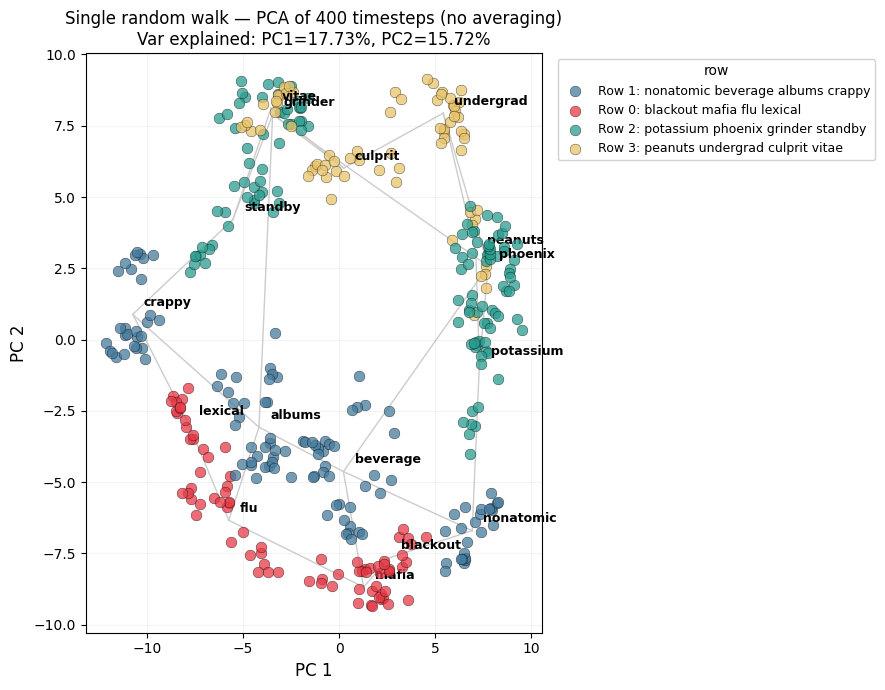

In [50]:
ROW_COLORS = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']

CONTEXT_LEN = 1800 # in {300, 600, 1200, 1800}

VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
GRID_PATH  = Path("../data/one_random_walk/grid_16/grid_dataset_structure.txt")
EMB_PATH   = Path(f"../embeddings/one_random_walk/grid_16/reprs_grid_dataset_one_rw_{CONTEXT_LEN}_line000000_layer26.pt")

token_to_id, id_to_token = load_token_id_map(VOCAB_PATH)
GRID, WORD_TO_POS, WORD_TO_TID, ID_TO_WORD, ROW_LABELS = load_grid_structure(GRID_PATH, token_to_id)

all_ids_np, all_emb_np = load_embeddings_pt(EMB_PATH)

print("GRID:")
for row in GRID:
    print(row)

print("\nRow labels:", ROW_LABELS)
print(f"\nEmbeddings shape: {all_emb_np.shape}, ids shape: {all_ids_np.shape}")

token_to_id, id_to_token = load_token_id_map(VOCAB_PATH)

# 2) griglia + dizionari
GRID, WORD_TO_POS, WORD_TO_TID, ID_TO_WORD, ROW_LABELS = load_grid_structure(GRID_PATH, token_to_id)

# 3) embeddings
all_ids_np, all_emb_np = load_embeddings_pt(EMB_PATH)

res = plot_window_pca_grid(
    all_ids_np=all_ids_np,
    all_emb_np=all_emb_np,
    GRID=GRID,
    WORD_TO_POS=WORD_TO_POS,
    WORD_TO_TID=WORD_TO_TID,
    ID_TO_WORD=ID_TO_WORD,
    row_colors=ROW_COLORS,
    row_labels=ROW_LABELS,
    NW=400,
    title_prefix="Single random walk",
)

GRID:
['apple', 'bird', 'car', 'egg']
['house', 'milk', 'plane', 'opera']
['box', 'sand', 'sun', 'mango']
['rock', 'math', 'code', 'phone']

Row labels: ['Row 0: apple bird car egg', 'Row 1: house milk plane opera', 'Row 2: box sand sun mango', 'Row 3: rock math code phone']

Embeddings shape: (500, 4096), ids shape: (500,)
Window: 200 timesteps (file length 500)
Unique tokens in window: 16


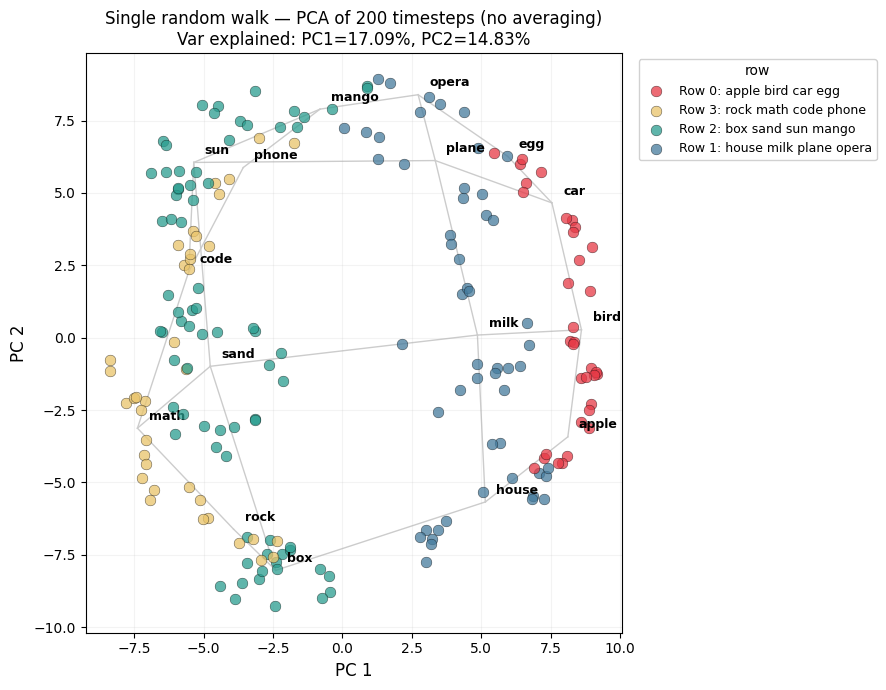

In [48]:

CONTEXT_LEN = 1800 # in {300, 600, 1200, 1800}

VOCAB_PATH = Path("../data/paper-tkid-map.txt")
GRID_PATH  = Path("../data/one_random_walk/paper_grid/paper_grid_structure.txt")
EMB_PATH   = Path(f"../embeddings/one_random_walk/paper_grid/reprs_paper_grid_one_rw_{CONTEXT_LEN}_line000000_layer26.pt")

token_to_id, id_to_token = load_token_id_map(VOCAB_PATH)
GRID, WORD_TO_POS, WORD_TO_TID, ID_TO_WORD, ROW_LABELS = load_grid_structure(GRID_PATH, token_to_id)

all_ids_np, all_emb_np = load_embeddings_pt(EMB_PATH)

print("GRID:")
for row in GRID:
    print(row)

print("\nRow labels:", ROW_LABELS)
print(f"\nEmbeddings shape: {all_emb_np.shape}, ids shape: {all_ids_np.shape}")

token_to_id, id_to_token = load_token_id_map(VOCAB_PATH)

# 2) griglia + dizionari
GRID, WORD_TO_POS, WORD_TO_TID, ID_TO_WORD, ROW_LABELS = load_grid_structure(GRID_PATH, token_to_id)

# 3) embeddings
all_ids_np, all_emb_np = load_embeddings_pt(EMB_PATH)

res = plot_window_pca_grid(
    all_ids_np=all_ids_np,
    all_emb_np=all_emb_np,
    GRID=GRID,
    WORD_TO_POS=WORD_TO_POS,
    WORD_TO_TID=WORD_TO_TID,
    ID_TO_WORD=ID_TO_WORD,
    row_colors=ROW_COLORS,
    row_labels=ROW_LABELS,
    NW=200,
    title_prefix="Single random walk",
)